In [ ]:
%pip install gymnasium 

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True
)

In [5]:
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

Observation space: Discrete(16)
Action space: Discrete(4)
Number of states: 16
Number of actions: 4


In [7]:
state, info = env.reset(seed=42)

print("Initial state:", state)
print("Info:", info)

Initial state: 0
Info: {'prob': 1}


In [8]:
action = env.action_space.sample()

print("Selected action:", action)

Selected action: 2


In [9]:
next_state, reward, terminated, truncated, info = env.step(action)

In [10]:
print("Next state:", next_state)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Info:", info)

Next state: 1
Reward: 0
Terminated: False
Truncated: False
Info: {'prob': 0.3333333333333333}


In [11]:
num_episodes = 10000

successes = 0
episode_lengths = []

rng = np.random.default_rng(42)

state, info = env.reset(seed=42)

for episode in range(num_episodes):

    if episode > 0:
        state, info = env.reset()

    done = False
    steps = 0

    while not done:

        action = rng.integers(env.action_space.n)

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        state = next_state
        steps += 1

    successes += reward
    episode_lengths.append(steps)

In [12]:
success_rate = successes / num_episodes

print(f"Successful episodes: {int(successes)} / {num_episodes}")
print(f"Success rate: {100 * success_rate:.2f}%")
print(f"Average episode length: {np.mean(episode_lengths):.2f} steps")

Successful episodes: 164 / 10000
Success rate: 1.64%
Average episode length: 7.70 steps


In [33]:
# Q-table
Q = np.zeros(
    (env.observation_space.n,
     env.action_space.n)
)

# Hyperparameters
alpha = 0.8
gamma = 0.95

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.9995

num_episodes = 20000

# Random number generator
rng = np.random.default_rng(42)

# Store the reward from every episode
training_rewards = []

for episode in range(num_episodes):

    state, info = env.reset()

    terminated = False
    truncated = False

    episode_reward = 0

    while not (terminated or truncated):

        # ----------------------------------------
        # 1. Choose action using epsilon-greedy
        # ----------------------------------------

        if rng.random() < epsilon:

            # Exploration
            action = rng.integers(
                env.action_space.n
            )

        else:

            # Exploitation
            max_actions = np.flatnonzero(
                Q[state] == np.max(Q[state])
            )

            action = rng.choice(max_actions)

        # ----------------------------------------
        # 2. Perform action
        # ----------------------------------------

        next_state, reward, terminated, truncated, info = \
            env.step(action)

        # ----------------------------------------
        # 3. Calculate Q-learning target
        # ----------------------------------------

        if terminated:

            target = reward

        else:

            target = (
                reward
                + gamma * np.max(Q[next_state])
            )

        # ----------------------------------------
        # 4. Update Q(s,a)
        # ----------------------------------------

        Q[state, action] += (
            alpha
            * (target - Q[state, action])
        )

        # ----------------------------------------
        # 5. Move to next state
        # ----------------------------------------

        state = next_state
        episode_reward += reward

    # Store whether this episode succeeded
    training_rewards.append(episode_reward)

    # ----------------------------------------
    # 6. Reduce exploration
    # ----------------------------------------

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

In [34]:
np.set_printoptions(
    precision=3,
    suppress=True
)

print(Q)

[[0.209 0.086 0.042 0.043]
 [0.002 0.009 0.006 0.096]
 [0.01  0.008 0.008 0.112]
 [0.01  0.003 0.004 0.018]
 [0.246 0.011 0.021 0.021]
 [0.    0.    0.    0.   ]
 [0.021 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.029 0.021 0.031 0.383]
 [0.035 0.738 0.024 0.   ]
 [0.188 0.005 0.002 0.009]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.099 0.112 0.93  0.006]
 [0.188 0.999 0.518 0.261]
 [0.    0.    0.    0.   ]]


In [35]:
policy = np.argmax(Q, axis=1)

print(policy.reshape(4, 4))

[[0 3 3 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]


In [36]:
action_symbols = np.array([
    "←", "↓", "→", "↑"
])

policy_symbols = action_symbols[policy]

print(policy_symbols.reshape(4, 4))

[['←' '↑' '↑' '↑']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]


In [37]:
num_test_episodes = 10000

successes = 0
episode_lengths = []

for episode in range(num_test_episodes):

    state, info = env.reset()

    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):

        # Pure exploitation
        max_actions = np.flatnonzero(
            Q[state] == np.max(Q[state])
        )

        action = rng.choice(max_actions)

        next_state, reward, terminated, truncated, info = \
            env.step(action)

        state = next_state
        steps += 1

    successes += reward
    episode_lengths.append(steps)

In [38]:
success_rate = successes / num_test_episodes

print(
    f"Successful episodes: "
    f"{int(successes)} / {num_test_episodes}"
)

print(
    f"Success rate: "
    f"{100 * success_rate:.2f}%"
)

print(
    f"Average episode length: "
    f"{np.mean(episode_lengths):.2f} steps"
)

Successful episodes: 7374 / 10000
Success rate: 73.74%
Average episode length: 44.36 steps


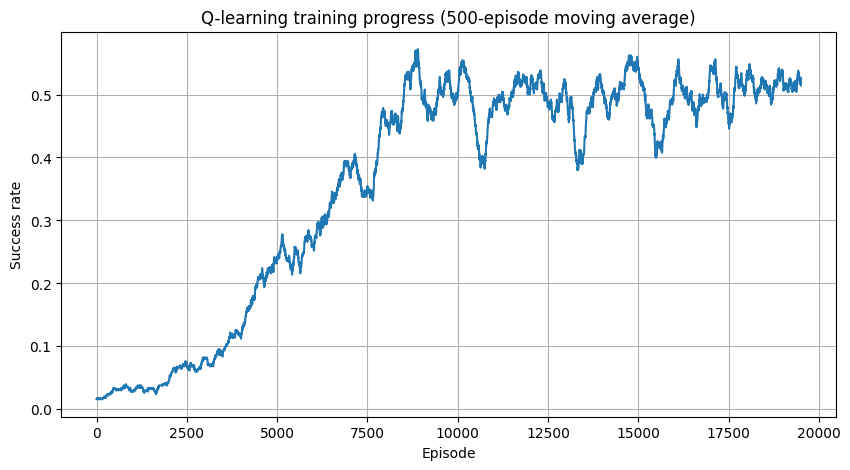

In [39]:
window = 500

moving_success_rate = np.convolve(
    training_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(moving_success_rate)

plt.xlabel("Episode")
plt.ylabel("Success rate")
plt.title(
    f"Q-learning training progress "
    f"({window}-episode moving average)"
)

plt.grid()

plt.show()